<a href="https://colab.research.google.com/github/saidanirafeek2011/Assignment-3-Data-Visualization.ipynb/blob/main/Assignment_8_Clustering_and_Dimensionality_Reduction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [3]:
file_path = r"/content/mall_customer_spend.xlsx"

df = pd.read_excel(file_path)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**Task 1: Data Exploration & Preprocessing**

In [4]:
df.shape

(200, 5)

In [5]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
df.dtypes

,0
CustomerID,int64
Genre,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [7]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [8]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


**Scale Numerical Features**

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler() #Creates a StandardScaler object.

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

 #Shows the first 5 scaled rows.

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

**TASK 2 : K-Means Clustering**

In [12]:
from sklearn.cluster import KMeans

In [14]:
random_state=10
# we need to create another K-Means model with a different random state.

In [16]:
# Change Random Initialization
kmeans_random2 = KMeans(n_clusters=5, random_state=50)
kmeans_random2.fit(X_scaled)
labels_2 = kmeans_random2.labels_
labels_2[:10]

array([0, 1, 0, 1, 0, 1, 0, 1, 4, 1], dtype=int32)

In [17]:
kmeans_random1 = KMeans(n_clusters=5, random_state=10)

kmeans_random1.fit(X_scaled)

labels_1 = kmeans_random1.labels_

labels_1[:10]

array([1, 3, 1, 3, 1, 3, 1, 3, 2, 3], dtype=int32)

In [18]:
kmeans_random2 = KMeans(n_clusters=5, random_state=50)

kmeans_random2.fit(X_scaled)

labels_2 = kmeans_random2.labels_

labels_2[:10]

array([0, 1, 0, 1, 0, 1, 0, 1, 4, 1], dtype=int32)

In [19]:
# Elbow Method to determine the optimal number of clusters
inertia_values = []

In [20]:
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

In [21]:
inertia_values

[599.9999999999999,
 389.38618895643714,
 295.4562449213557,
 205.22514747675913,
 169.89149793438568,
 134.35277477401493,
 121.38935022502866,
 113.72723000071333,
 102.13623844329251,
 92.55027231838784]

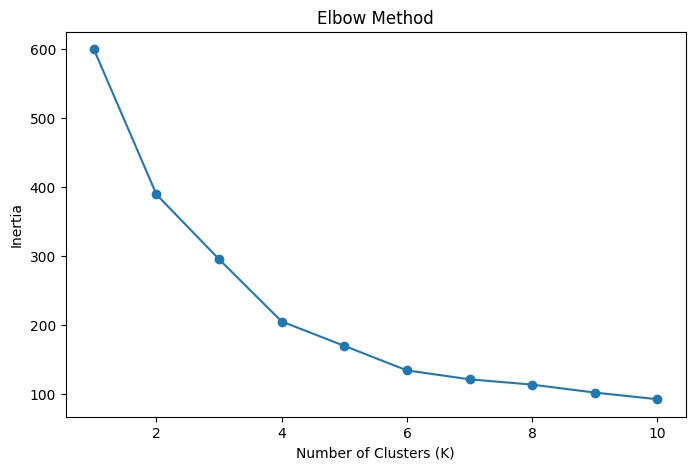

In [22]:
#Plot Elbow Graph
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia_values, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [24]:
# Optimal Number of Clusters = 5
n_clusters = 5

**Build Final K-Means Model**

In [25]:
final_kmeans = KMeans(n_clusters=5, random_state=42)
final_kmeans.fit(X_scaled)

KMeans(n_clusters=5, random_state=42)

In [26]:
cluster_labels = final_kmeans.labels_
cluster_labels[:10]

array([2, 2, 3, 2, 2, 2, 3, 2, 0, 2], dtype=int32)

**Task 3: Hierarchical Clustering**

In [27]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
# Create Dendrogram

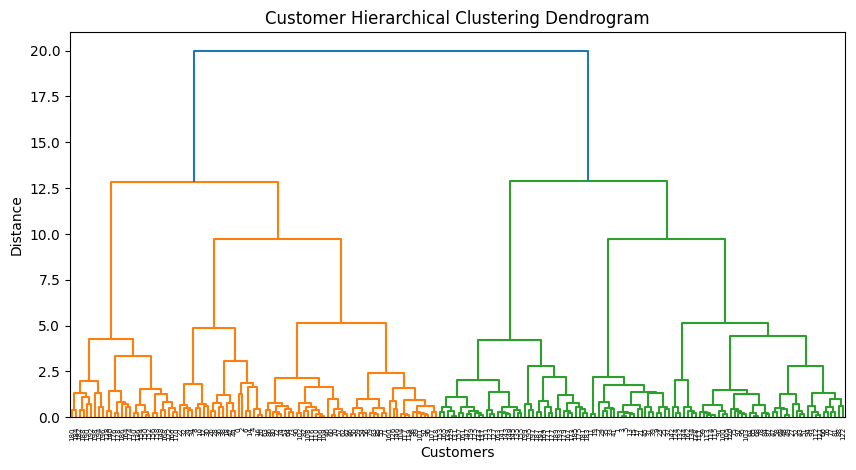

In [28]:
# Creating linkage using Ward method
hierarchy = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(10,5))
dendrogram(hierarchy)

plt.title("Customer Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

In [29]:
from sklearn.cluster import AgglomerativeClustering
# Apply Agglomerative Hierarchical Clustering

In [30]:
# Creating hierarchical clustering model
hierarchical_model = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

# Assigning cluster labels
hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

# Display first 10 cluster labels
hierarchical_labels[:10]

array([4, 0, 4, 0, 4, 0, 4, 0, 4, 0])

In [31]:
# Compare cluster formation with K-Means
hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

print("K-Means Cluster Labels:")
print(cluster_labels[:10])

print("\nHierarchical Cluster Labels:")
print(hierarchical_labels[:10])

K-Means Cluster Labels:
[2 2 3 2 2 2 3 2 0 2]

Hierarchical Cluster Labels:
[4 0 4 0 4 0 4 0 4 0]


**TASK 4: DBSCAN Clustering**

In [32]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
# Apply DBSCAN Model

In [33]:
# Creating DBSCAN model
dbscan_model = DBSCAN(eps=0.5, min_samples=5)

# Predicting clusters
dbscan_labels = dbscan_model.fit_predict(X_scaled)

# Display first 10 labels
dbscan_labels[:10]

array([-1,  0, -1,  0, -1,  0, -1, -1, -1,  0])

In [34]:
# Identification of Clusters and Noise Points

# Count clusters
clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# Count noise points
noise = list(dbscan_labels).count(-1)

print("Number of clusters:", clusters)
print("Number of noise points:", noise)

Number of clusters: 6
Number of noise points: 60


In [35]:
# Compare DBSCAN with K-Means and Hierarchical Clustering

print("K-Means Clusters:")
print(cluster_labels[:10])

print("\nHierarchical Clusters:")
print(hierarchical_labels[:10])

print("\nDBSCAN Clusters:")
print(dbscan_labels[:10])

K-Means Clusters:
[2 2 3 2 2 2 3 2 0 2]

Hierarchical Clusters:
[4 0 4 0 4 0 4 0 4 0]

DBSCAN Clusters:
[-1  0 -1  0 -1  0 -1 -1 -1  0]


**TASK 5: Dimensionality Reduction**

In [36]:
from sklearn.decomposition import PCA
#  Apply PCA

In [37]:
pca = PCA(n_components=2)

# Transform scaled data
pca_data = pca.fit_transform(X_scaled)

# View first 5 rows
pca_data[:5]

array([[-0.61572002, -1.76348088],
       [-1.66579271, -1.82074695],
       [ 0.33786191, -1.67479894],
       [-1.45657325, -1.77242992],
       [-0.03846521, -1.66274012]])

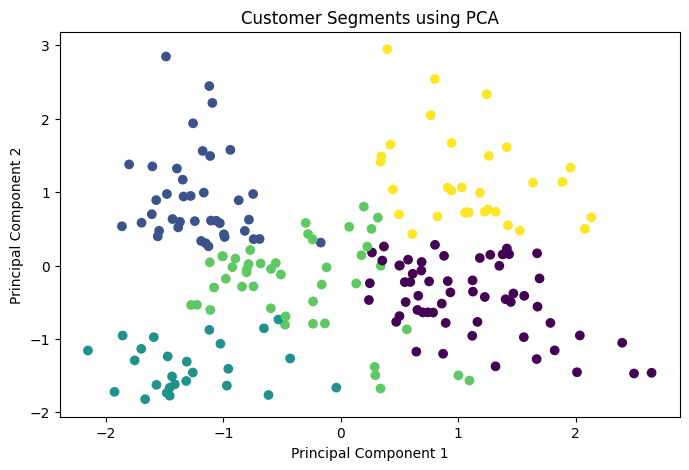

In [39]:
# Visualize PCA Result
plt.figure(figsize=(8,5))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=cluster_labels
)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [40]:
from sklearn.manifold import TSNE
# Creating t-SNE model
tsne = TSNE(n_components=2, random_state=42)

# Transform data into 2 dimensions
tsne_data = tsne.fit_transform(X_scaled)

# View first 5 rows
tsne_data[:5]

array([[-0.6994132 , -5.2161818 ],
       [-6.678774  , -4.357728  ],
       [ 0.6059619 , -6.7314305 ],
       [-6.2205405 , -4.390894  ],
       [ 0.26713365, -5.2442904 ]], dtype=float32)

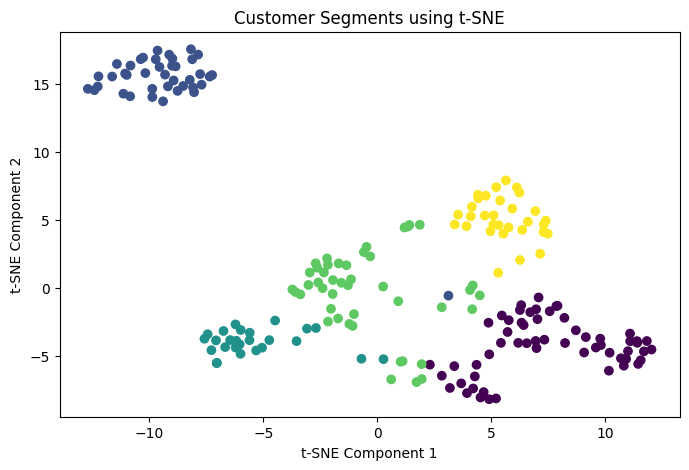

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    tsne_data[:,0],
    tsne_data[:,1],
    c=cluster_labels
)

plt.title("Customer Segments using t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.show()

**Task 6: Cluster Analysis**

In [43]:
# Cluster Analysis
# Add Cluster Labels to Dataset

In [44]:
# Add K-Means cluster labels to original data

df['Cluster'] = cluster_labels

# Display first 5 rows
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,3
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [49]:
# Analyze Average Customer Characteristics

# Find average values for each cluster

# Add K-Means cluster labels to original dataset

df['Cluster'] = cluster_labels

# Calculate average values for each cluster
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

# Display cluster summary
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

cluster_summary


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,68.775862,55.275862,47.620690,41.706897
1,161.025000,32.875000,86.100000,81.525000
2,23.461538,25.769231,26.115385,74.846154
3,86.377778,26.733333,54.311111,40.911111
4,166.870968,44.387097,89.774194,18.483871
